<a href="https://colab.research.google.com/github/anoushkachatterjee123/Sleep-Pattern-Recognition-for-Paediatric-ADHD/blob/main/Sleep_Pattern_Recognition_for_ADHD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving patient_info (1).csv to patient_info (1) (10).csv
Dataset Preview:
   ID  SEX  AGE  ACC  ACC_TIME  ACC_DAYS  HRV  HRV_TIME  HRV_HOURS  CPT_II  \
0   1    0    3    1  16:00:00       6.0    1  11:00:00       21.0       0   
1   2    0    4    1  10:54:00       6.8    0       NaN        NaN       1   
2   3    1    2    1  15:28:00       7.2    1  15:25:00       21.0       1   
3   4    1    3    0       NaN       NaN    1  16:55:00       22.0       1   
4   5    1    1    1  14:24:00       5.9    1  16:00:00       12.0       1   

   ...  HADS_D  MED  MED_Antidepr  MED_Moodstab  MED_Antipsych  \
0  ...     2.0    1           1.0           NaN            NaN   
1  ...     7.0    0           NaN           NaN            NaN   
2  ...     0.0    0           NaN           NaN            NaN   
3  ...     6.0    1           1.0           NaN            NaN   
4  ...     5.0    0           NaN           NaN            NaN   

   MED_Anxiety_Benzo  MED_Sleep  MED_Analgesics_Opioids  MED

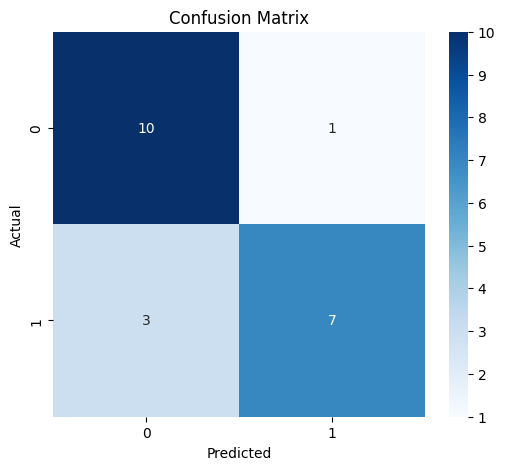

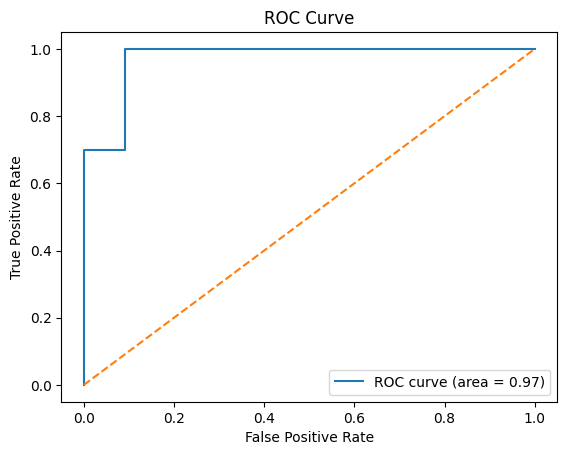


AUC Score: 0.9727
  → AUC is strong: Model discriminates well between ADHD and non-ADHD.

Feature Importance:
                   Feature  Importance
16                    WURS    0.208625
8                      ADD    0.138391
17                    ASRS    0.134961
0                       ID    0.077652
4                 ACC_DAYS    0.057260
18                   MADRS    0.044747
19                  HADS_A    0.044385
11                 ANXIETY    0.037288
20                  HADS_D    0.037044
12               SUBSTANCE    0.031297
13                   OTHER    0.025074
6                HRV_HOURS    0.024626
9                  BIPOLAR    0.017174
2                      AGE    0.014035
5                      HRV    0.014018
29                filter_$    0.013135
15                 MDQ_POS    0.013015
14                      CT    0.012141
23            MED_Moodstab    0.010656
3                      ACC    0.010242
10                UNIPOLAR    0.009343
1                      SEX    0

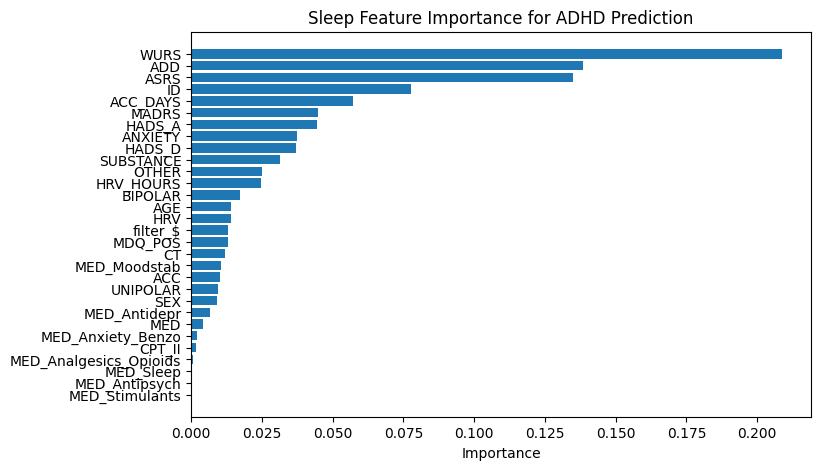


Model saved as sleep_adhd_model.pkl


In [ ]:
# ---------------------------------------------------------
# 1. IMPORT LIBRARIES
# ---------------------------------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import train_test_split, GridSearchCV # Added GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from google.colab import files

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    f1_score
)
# ---------------------------------------------------------
# 2. LOAD DATASET
# ---------------------------------------------------------


uploaded = files.upload()
# Example dataset file
df = pd.read_csv("patient_info (1).csv", delimiter=';')

print("Dataset Preview:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# ---------------------------------------------------------
# 3. DATA CLEANING
# ---------------------------------------------------------

# Create a copy t9jo avoid modifying the original df directly if it's used elsewhere
df_processed = df.copy()

# Drop object columns that are not directly usable as numerical features
# or that require more complex feature engineering not specified here.
df_processed = df_processed.drop(columns=['ACC_TIME', 'HRV_TIME'], errors='ignore')

# Target column
target = "ADHD"

# Identify numeric columns for features, excluding the target 'ADHD'
# This list will now only contain columns that are numbers after dropping object types
numeric_cols_for_imputation = df_processed.select_dtypes(include=np.number).columns.tolist()
if target in numeric_cols_for_imputation:
    numeric_cols_for_imputation.remove(target);

# Impute missing values
# For 'MED_' columns, fill NaN with 0, assuming NaN means 'not taking that medication'
medication_cols = [col for col in numeric_cols_for_imputation if col.startswith('MED_')]
for col in medication_cols:
    df_processed[col] = df_processed[col].fillna(0)

# For other numerical columns, impute with the median
other_numeric_cols = [col for col in numeric_cols_for_imputation if col not in medication_cols]
for col in other_numeric_cols:
    if df_processed[col].isnull().any():
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# The target column 'ADHD' has no missing values, so no special handling is needed.

# ---------------------------------------------------------
# 4. FEATURE SELECTION
# ---------------------------------------------------------

# Features and target for the model are now from df_processed
X = df_processed[numeric_cols_for_imputation]
y = df_processed[target]

print("\nFeatures used for prediction:")
print(X.columns)

# ---------------------------------------------------------
# 5. DATA NORMALIZATION
# ---------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
# ---------------------------------------------------------
# 6. TRAIN TEST SPLIT
# ---------------------------------------------------------

train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))
# ---------------------------------------------------------
# 7. TRAIN MACHINE LEARNING MODEL (with Hyperparameter Tuning)
# ---------------------------------------------------------

# Define a wider parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV with more folds
cv_strategy = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best estimator
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("\nBest Hyperparameters found:", best_params)

# Use the best estimator as our final model
model = best_estimator

# ---------------------------------------------------------
# 8. MAKE PREDICTIONS
# ---------------------------------------------------------

y_pred = model.predict(X_test)

# ---------------------------------------------------------
# 9. MODEL EVALUATION
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

mcc = matthews_corrcoef(y_test, y_pred)
print("Matthews Correlation Coefficient:", round(mcc, 4))
bal_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", round(bal_acc, 4))
f1 = f1_score(y_test, y_pred)
print("F1 Score:", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# ---------------------------------------------------------
# 10. CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ---------------------------------------------------------
# 11. ROC CURVE
# ---------------------------------------------------------

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("\nAUC Score:", round(roc_auc, 4))
if roc_auc >= 0.85:
    print("  → AUC is strong: Model discriminates well between ADHD and non-ADHD.")
elif roc_auc >= 0.70:
    print("  → AUC is acceptable.")
else:
    print("  → AUC is low: Consider feature engineering or different model.")

# ---------------------------------------------------------
# 12. FEATURE IMPORTANCE
# ---------------------------------------------------------

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print("\nFeature Importance:")
print(feature_importance)

# Plot feature importance

plt.figure(figsize=(8,5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Sleep Feature Importance for ADHD Prediction")

plt.gca().invert_yaxis()

plt.show()

# ---------------------------------------------------------
# 13. SAVE TRAINED MODEL
# ---------------------------------------------------------

import joblib

joblib.dump(model, "sleep_adhd_model.pkl")

print("\nModel saved as sleep_adhd_model.pkl")